In [ ]:
# Assignment 1

import pandas as pd
import numpy as np
def interval_estimate (Flag, n, mean, sigma):
    try:
        z = {'0.025':1.96, '0.05':1.68}
        t = {'15':{'0.025':2.131, '0.05':1.753},
             '16':{'0.025':2.120, '0.05':1.746},
             '17':{'0.025':2.110, '0.05':1.740},
             '18':{'0.025':2.101, '0.05':1.734},
             '19':{'0.025':2.093, '0.05':1.729},
            }
        
        if n > 30:
            if Flag == 'Point':
                pointEst = meanmetric = print('Given distribution is z-distribution. Calculated metric is point estimate and the value is {}'.format(pointEst))
                return pointEst, metric
            
            elif Flag == 'Interval':
                LintervalEst = mean - (z['0.025'])*sigma/(n**0.5)
                HintervalEst = mean + (z['0.025'])*sigma/(n**0.5)
                intervalEst = (LintervalEst, HintervalEst )
                metric = print('Given distribution is z-distribution. Calculated metric is interval estimate. The lower percentile is {} and the higher percentile is {}'.format(LintervalEst, HintervalEst))
                return intervalEst, metric
        
        elif n <= 30:
            dof = n-1
            sample = cereal['calories'].sample(n = 29, random_state=1)   #Taking sample size less than 30. 
            ssd = sample.mean() # Calculating the Sample Standard Deviation seperately for t-Distribution intervals 
            if Flag == 'Point':
                pointEst = mean
                metric = print('Given distribution is t-distribution. Calculated metric is point estimate and the value is {}'.format(pointEst))
                return pointEst, metric
            
            elif Flag == 'Interval':
                LintervalEst = mean - t[dof]['0.025']*ssd/(n**0.5)
                HintervalEst = mean + t[dof]['0.025']*ssd/(n**0.5)
                intervalEst = (LintervalEst, HintervalEst )
                metric = print('Given distribution is t-distribution. Calculated metric is interval estimate. The lower percentile is {} and the higher percentile is {}'.format(LintervalEst, HintervalEst))
                return intervalEst, metric 
        
    except ZeroDivisionError as e:
        print('division by zero invalid.')
    except ValueError:
        print('Error... trying to convert string to integer.')
    except:
        print('Error.. invalid inputs')

In [ ]:
# Assignment 2: Write a correlation function which can give the uncorrelated variable in the output for model building. 
# Basically remove manual lookup of correlation matrix by the data scientist. 

import pandas as pd
import numpy as np

def correlation(data):
    
    data.head()
    df = pd.DataFrame(data)
    cormatrix = df.corr().abs()
    print(cormatrix)
    
    upper_tri = cormatrix.where(np.triu(np.ones(cormatrix.shape),k=1).astype(np.bool))
    print(upper_tri)
    
    to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > 0.75)]
    print(to_drop)
    
    df1 = df.drop(df.columns[to_drop], axis=1)
    return df1

data = pd.read_csv('C:/Users/DeepaK/Desktop/My Folder/My Learnings/cereal.csv', encoding='latin-1')
print(correlation(data))

In [5]:
# Assignment 3 : Hypothesis Testing

import pandas as pd
import numpy as np
import warnings
import random
warnings.filterwarnings('ignore')

cereal = pd.read_csv('C:/Users/DeepaK/Desktop/My Folder/My Learnings/cereal.csv', encoding='latin-1')
cereal.head()
cereal.shape[0]
test = cereal['calories'].sample(n = 30, random_state=1)
abs(test.mean())
def hyp_tes(cereal, alpha):
    try:
        mean  = cereal['calories'].mean()
        sigma = cereal['calories'].std()
        n = cereal.shape[0]
        xbar = test.mean()
        t, z = 0
        dof = n-1
        zt = {'0.025':1.96, '0.05':1.68}
        tt = {'15':{'0.025':2.131, '0.05':1.753},
             '16':{'0.025':2.120, '0.05':1.746},
             '17':{'0.025':2.110, '0.05':1.740},
             '18':{'0.025':2.101, '0.05':1.734},
             '19':{'0.025':2.093, '0.05':1.729},
            }
        if n <= 30: 
            print('It is a t test/n')
            Flag = 0
        else:
            print('It is a z test/n')
            Flag = 1
            
        if Flag == '0':
            t = ( xbar - mean ) / (sigma / n**0.5)
            talpha = tt[dof][alpha/2]    
            if t <= talpha: 
                print('Null Hypothesis is accepted.')
            else:
                print('Null hypothesis is rejected.')
        if flag == '1':
            z = ( xbar - mean) / (sigma / n**0.5)
            z1 = alpha/2 # Incase of two-tail
            zalpha = zt['z1']
            if z <= zalpha:
                print('Null Hypothesis is accepted.')
            else:
                print('Null hypothesis is rejected.')
    
    except ZeroDivisionError as e:
        print('division by zero invalid.')
    except ValueError:
        print('Error.....trying to convert string to integer.')
    except:
        print('Error.. invalid inputs')

In [2]:
# Assignment 4: Manually obtain highest possible accuracy by experimenting on hyper parameters in CART 

import pandas as pd
import numpy as np
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
from six import StringIO 
from IPython.display import Image  
from sklearn.tree import export_graphviz
import pydotplus

In [6]:
df = pd.read_csv("C:/Users/DeepaK/Desktop/My Folder/My Learnings/bank.csv", na_values =['NA'])
temp = df.columns.values
temp

array(['age', 'job', 'marital', 'education', 'default', 'balance',
       'housing', 'loan', 'contact', 'day', 'month', 'duration',
       'campaign', 'pdays', 'previous', 'poutcome', 'deposit'],
      dtype=object)

In [7]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [8]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


In [9]:
df.shape

(11162, 17)

In [10]:
contact_df = df
contact_df.head()
contact_df.shape

(11162, 17)

## Spending Sweat & Blood!

In [11]:
# 1. Checking & Removing nulls / Missing values

totalnulls = contact_df.isnull().sum().sort_values(ascending=True)
missing_data = pd.concat([totalnulls], axis=1, keys=['Totalnulls'])
missing_data.head()

,Totalnulls
age,0
previous,0
pdays,0
campaign,0
duration,0


In [12]:
# 2. C & R Outliers

import matplotlib.pyplot as plt
# plt.hist(contact_df.Values)
# plt.show()

# Outliers are possible only in 3 columns: balance, Day, Duration.

durminth, durmaxth = contact_df.duration.quantile([0.001, 0.999])
balminthreshold, balmaxthreshold = contact_df.balance.quantile([0.001, 0.999])
dayminth, daymaxth = contact_df.day.quantile([0.001, 0.999])

contact_df = contact_df[(contact_df.balance > balminthreshold) &
                   (contact_df.balance < balmaxthreshold) &
                   (contact_df.day > dayminth) &
                   (contact_df.day < daymaxth) &
                   (contact_df.duration > durminth) &
                   (contact_df.duration < durmaxth)
                  ]
contact_df.shape
# print(dayminth, daymaxth)
# print(durminth, durmaxth)

(10853, 17)

In [13]:
# 3. C & R duplicates

contact_df.duplicated().sum() 

0

In [14]:
contact_df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [15]:
# 4. Removing unimportant features

contact_df = contact_df.drop(['poutcome', 'pdays', 'previous'], axis = 1)
contact_df 

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11157,33,blue-collar,single,primary,no,1,yes,no,cellular,20,apr,257,1,no
11158,39,services,married,secondary,no,733,no,no,unknown,16,jun,83,4,no
11159,32,technician,single,secondary,no,29,no,no,cellular,19,aug,156,2,no
11160,43,technician,married,secondary,no,0,no,yes,cellular,8,may,9,2,no


In [16]:
#5. Checking & Removing correlation

featuresmatrix = contact_df.drop('deposit', axis = 1)
targetfeature = contact_df['deposit']
contact_df.shape

(10853, 14)

In [17]:
x_train, x_test, y_train, y_test = train_test_split(featuresmatrix,targetfeature,test_size =0.2)
x_train.shape, y_train.shape

((8682, 13), (8682,))

In [18]:
x_train.corr()  

,age,balance,day,duration,campaign
age,1.000000,0.106942,-0.007282,-0.007303,-0.004515
balance,0.106942,1.000000,0.014074,0.033694,-0.015029
day,-0.007282,0.014074,1.000000,-0.021632,0.107876
duration,-0.007303,0.033694,-0.021632,1.000000,-0.035707
campaign,-0.004515,-0.015029,0.107876,-0.035707,1.000000


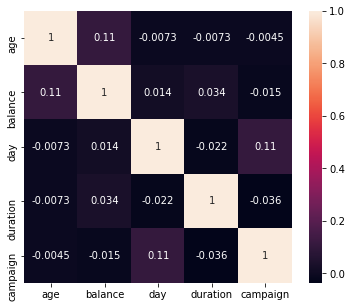

In [19]:
import seaborn as sns             # Visualizing correlation through heatmap
plt.figure(figsize = (6,5))
cor = x_train.corr()
sns.heatmap(cor, annot = True)
plt.show()

In [20]:
# Function for correlation

def correlation (dataset, threshold):     
    col_corr = set()
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range (i):
            if abs(corr_matrix.iloc[i,j]) > threshold:
                colname = corr_matrix.columns[i]
                col_corr.add(colname)
            return col_corr

In [21]:
corr_features = correlation(x_train, 0.8)
len(set(corr_features))

# Proves that no correlation found amongst the independent features of the training dataset. 

0

In [22]:
def preprocessor(df):
    res_df = df.copy()
    le = preprocessing.LabelEncoder()
    
    res_df['job'] = le.fit_transform(res_df['job'])
    res_df['marital'] = le.fit_transform(res_df['marital'])
    res_df['education'] = le.fit_transform(res_df['education'])
    res_df['default'] = le.fit_transform(res_df['default'])
    res_df['housing'] = le.fit_transform(res_df['housing'])
    res_df['month'] = le.fit_transform(res_df['month'])
    res_df['loan'] = le.fit_transform(res_df['loan'])
    res_df['contact'] = le.fit_transform(res_df['contact'])
    res_df['day_of_week'] = le.fit_transform(res_df['day'])
    res_df['deposit'] = le.fit_transform(res_df['deposit'])
    return res_df

In [23]:
encoded_df = preprocessor(contact_df)
print(encoded_df)
encoded_df.shape
x = encoded_df.drop(['deposit'],axis =1).values    # Dropping TV Deposit
y = encoded_df['deposit'].values

       age  job  marital  education  default  balance  housing  loan  contact  \
0       59    0        1          1        0     2343        1     0        2   
1       56    0        1          1        0       45        0     0        2   
2       41    9        1          1        0     1270        1     0        2   
3       55    7        1          1        0     2476        1     0        2   
4       54    0        1          2        0      184        0     0        2   
...    ...  ...      ...        ...      ...      ...      ...   ...      ...   
11157   33    1        2          0        0        1        1     0        0   
11158   39    7        1          1        0      733        0     0        2   
11159   32    9        2          1        0       29        0     0        0   
11160   43    9        1          1        0        0        0     1        0   
11161   34    9        1          1        0        0        0     0        0   

       day  month  duration

In [24]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size =0.2)
print(x_train.shape)
print(y_train.shape)


(8682, 14)
(8682,)


In [25]:
# Decision tree as CART

model_dt_2 = DecisionTreeClassifier(min_samples_leaf = 21, min_samples_split = 70, max_features= None, random_state=1, max_depth=11)
model_dt_2.fit(x_train, y_train)
model_dt_2_score_train = model_dt_2.score(x_train, y_train)
print("Training score: ",model_dt_2_score_train)
model_dt_2_score_test = model_dt_2.score(x_test, y_test)
y_pred_dt = model_dt_2.predict_proba(x_test)[:, 1]
print("Testing score: ",model_dt_2_score_test)

abs(y_pred_dt)

Training score:  0.8348306841741534
Testing score:  0.7918010133578995


array([0.17073171, 0.01923077, 0.6097561 , ..., 0.41025641, 0.75555556,
       0.        ])

In [26]:
# Assignment 5: Implement the Assignment 4 in Grid Search CV model

import time
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

np.random.seed(42)
start = time.time()

param_dist = {'min_samples_leaf': list(range(5,30)),
              'min_samples_split': list(range(10, 91, 5)),
              'criterion': ['gini'],
              'max_depth': [6,7,8,9,10,11]
             }

grid_search_cv = GridSearchCV(DecisionTreeClassifier(random_state=42), param_dist, verbose=1, cv=10, n_jobs = 3)


grid_search_cv.fit(x_train, y_train)

print('Best Parameters using grid search: \n', grid_search_cv.best_params_)
end = time.time()
print('Time taken in grid search: {0: .2f}'.format(end - start))

Fitting 10 folds for each of 2550 candidates, totalling 25500 fits


[Parallel(n_jobs=3)]: Using backend LokyBackend with 3 concurrent workers.
[Parallel(n_jobs=3)]: Done  52 tasks      | elapsed:    6.6s
[Parallel(n_jobs=3)]: Done 352 tasks      | elapsed:   14.9s
[Parallel(n_jobs=3)]: Done 852 tasks      | elapsed:   32.4s
[Parallel(n_jobs=3)]: Done 1552 tasks      | elapsed:   51.6s
[Parallel(n_jobs=3)]: Done 2732 tasks      | elapsed:  1.3min
[Parallel(n_jobs=3)]: Done 4932 tasks      | elapsed:  2.2min
[Parallel(n_jobs=3)]: Done 7532 tasks      | elapsed:  3.3min
[Parallel(n_jobs=3)]: Done 10532 tasks      | elapsed:  4.7min
[Parallel(n_jobs=3)]: Done 13932 tasks      | elapsed:  6.8min
[Parallel(n_jobs=3)]: Done 17732 tasks      | elapsed:  9.1min
[Parallel(n_jobs=3)]: Done 21932 tasks      | elapsed: 11.6min
[Parallel(n_jobs=3)]: Done 25500 out of 25500 | elapsed: 14.0min finished


Best Parameters using grid search: 
 {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 5, 'min_samples_split': 85}
Time taken in grid search:  838.42


In [27]:
# Assignment 6: Assignment 5:  Submit the csv. 1st column is x_test data, i.e. all my 20% features + y_test + predictions.
# Concatenation - Add these 3 columns to the cleaned csv. This is how we send data to customers, i.e. Need features,
# target variable & predictions.

import csv
# cleaned dataframe:contact_df | x_test, y_test, y_pred_dt

print(x_test.shape)
print(type(x_test))
ytests = pd.Series(y_test)
ypreddts = pd.Series(y_pred_dt)
type(y_pred_dts)

# The dataset was a dataframe object. When we split it into training & testing, it gets converted to np.ndarray object.
# Thus we need to convert x_test back to dataframe.

df = pd.DataFrame(x_test, columns = ['age', 'job', 'marital', 'education', 'default', 'balance','housing', 'loan', 
                                     'contact', 'day', 'month', 'duration', 'campaign', 'deposit'])

df['y_test'] = ytests
print('Predictions shpould be fractional as above : ', y_pred_dt)
df['y_predictions'] = abs(y_pred_dts)

df.head()

(2171, 14)
<class 'numpy.ndarray'>


NameError: name 'y_pred_dts' is not defined

In [ ]:
resul_df = pd.concat([df, ytests, y_pred_dts], axis=1)
final_result = resul_df.to_csv(r'C:\Users\DeepaK\Desktop\My Folder\My Learnings\final_result.csv', index = False)